## 1. Importación de librerías y carga del dataset limpio

Cargamos las librerías necesarias para el modelo (scikit-learn) 
y el dataset limpio generado en el EDA.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('Datasets/dataset_limpio_dashboard2.csv')
df.shape

(3872, 11)

In [4]:
df.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'PreInt_EduHx-computerinternet_hoursday', 'PCIAT-PCIAT_Total',
       'CGAS-CGAS_Score', 'SDS-SDS_Total_T', 'sii', 'Horas_Pantalla_Label',
       'Sexo_Label', 'Uso_Saludable'],
      dtype='str')

**Conclusiones:**

- 11 columnas confirmadas, todas esperadas: las 7 numéricas originales 
  + las 3 columnas añadidas en el paso 30-31 (Horas_Pantalla_Label, 
  Sexo_Label, Uso_Saludable) + id
- Dataset listo para preparar variables predictoras (X) y objetivo (y)

## 2. Selección de variables predictoras (X) y objetivo (y)

Definimos X (variables que usará el modelo para predecir) e y (sii, 
la variable objetivo). Excluimos id (identificador, no aporta información), 
las columnas de texto (Horas_Pantalla_Label, Sexo_Label, duplican 
información ya numérica) y PCIAT-PCIAT_Total (ya que sii se deriva 
directamente de ella - usarla sería "hacer trampa", el modelo 
aprendería la fórmula, no patrones reales).

In [5]:
X = df[['Basic_Demos-Age', 'Basic_Demos-Sex', 
        'PreInt_EduHx-computerinternet_hoursday', 
        'CGAS-CGAS_Score', 'SDS-SDS_Total_T']]

y = df['sii']

X.head()

,Basic_Demos-Age,Basic_Demos-Sex,PreInt_EduHx-computerinternet_hoursday,CGAS-CGAS_Score,SDS-SDS_Total_T
0,5,0,3,51,55
1,9,0,0,65,64
2,10,1,2,71,54
3,9,0,0,71,45
4,18,1,1,65,55


**Conclusiones:**

- X contiene 5 variables predictoras: edad, sexo, horas de pantalla, 
  CGAS_Score y SDS_Total_T
- y contiene la variable objetivo (sii), con 4 clases posibles (0-3)
- Se excluyó deliberadamente PCIAT-PCIAT_Total para evitar que el modelo 
  "haga trampa" aprendiendo la fórmula de sii en lugar de patrones reales
- Datos listos para dividir en conjuntos de entrenamiento y prueba

## 3. División en conjuntos de entrenamiento y prueba

Dividimos los datos: 80% para entrenar el modelo (train) y 20% 
para evaluarlo con datos que no ha visto (test). Usamos stratify=y 
para mantener la misma proporción de clases de sii en ambos conjuntos, 
ya que sabemos que están muy desbalanceadas.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '/ Test:', X_test.shape)

Train: (3097, 5) / Test: (775, 5)


**Conclusiones:**

- Train: 3.097 filas (80%), Test: 775 filas (20%)
- stratify=y asegura que ambos conjuntos mantienen la misma proporción 
  de cada nivel de sii (0,1,2,3) que el dataset completo (71%-19%-9%-1% 
  aproximadamente)
- random_state=42 garantiza que la división es reproducible
- Listos para entrenar el modelo

## 4. Entrenamiento del modelo Random Forest

Entrenamos un Random Forest Classifier con class_weight='balanced' 
para compensar el desbalance de clases en sii (recordemos: 71% son 
clase 0, solo 1% son clase 3).

In [7]:
modelo = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42
)

modelo.fit(X_train, y_train)

print('Modelo entrenado')

Modelo entrenado


**Conclusiones:**

- Modelo Random Forest entrenado correctamente con 100 árboles 
  y ajuste por desbalance de clases (class_weight='balanced')
- El modelo ha aprendido patrones a partir de 3.097 casos de entrenamiento, 
  usando edad, sexo, horas de pantalla, CGAS_Score y SDS_Total_T 
  para predecir el nivel de severidad (sii)
- Siguiente paso: evaluar qué tan bien predice usando los 775 casos 
  de test (que el modelo no ha visto durante el entrenamiento)

## 5. Evaluación del modelo: predicciones y accuracy

Usamos el modelo entrenado para predecir sii sobre el conjunto de test, 
y calculamos el accuracy general (% de predicciones correctas).

In [8]:
y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy, 4))

Accuracy: 0.6439


**Conclusiones:**

- El modelo predice correctamente el nivel de sii en el 64.39% 
  de los casos de test (775 casos)

- Para interpretar esto correctamente: si el modelo predijera siempre 
  "sii=0" (la clase mayoritaria, ~71% del dataset), tendría un accuracy 
  de ~71% SIN aprender nada útil

- Por tanto, un accuracy de 64.39% es MENOR que ese "baseline tonto" 
  → en términos de accuracy puro, el modelo parece "peor" que no hacer nada

- ⚠️ Pero esto es esperado y no necesariamente malo: con class_weight='balanced', 
  el modelo está intentando predecir TAMBIÉN las clases minoritarias 
  (1, 2, 3), lo cual baja el accuracy general pero puede mejorar 
  la detección de casos de riesgo real (que es lo que nos importa 
  para el Dashboard 2)

- Necesitamos mirar más allá del accuracy: la matriz de confusión 
  y el classification_report nos dirán si el modelo realmente 
  detecta los casos de riesgo (sii=2,3), aunque falle más en sii=0

## 6. Matriz de confusión

Visualizamos la matriz de confusión: en las filas, el valor real de sii; 
en las columnas, lo que predijo el modelo. La diagonal son aciertos, 
fuera de la diagonal son errores.

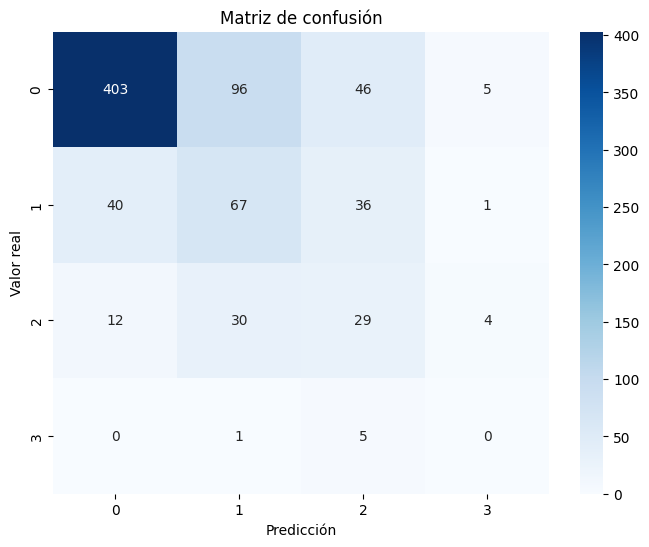

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión')
plt.show()

**Conclusiones:**

- **Clase 0 (sin problema, 550 casos reales)**: el modelo acierta 403 
  (73.3%), pero confunde 96 con clase 1, 46 con clase 2 y 5 con clase 3 
  → tiende a "sobre-predecir" riesgo en casos que en realidad no tienen problema

- **Clase 1 (leve, 144 casos reales)**: el modelo acierta 67 (46.5%), 
  confunde 40 con clase 0 y 36 con clase 2 → es la clase con más 
  confusión "en ambas direcciones"

- **Clase 2 (moderado, 75 casos reales)**: el modelo acierta 29 (38.7%), 
  confunde 12 con clase 0 y 30 con clase 1 → el modelo SÍ detecta 
  una parte importante de estos casos (no los ignora, a diferencia 
  de lo que haría un modelo "tonto" que siempre predice 0)

- **Clase 3 (severo, 6 casos reales)**: el modelo NO acierta ninguno 
  (0/6) → predice 1 caso como clase 1 y 5 como clase 2. Con solo 
  6 casos de test, es estadísticamente muy difícil que el modelo 
  aprenda este patrón

- **Patrón general**: el modelo tiende a predecir clases ADYACENTES 
  a la real (0↔1, 1↔2, 2↔3), rara vez se equivoca "a lo grande" 
  (ej: real=0, predicho=3 nunca ocurre). Esto es positivo: los errores 
  son "moderados", no extremos

- **Comparado con el baseline tonto** (predecir siempre 0, ~71% accuracy 
  pero 0% de detección en clases 1,2,3): este modelo SÍ detecta una 
  parte real de los casos de riesgo (67 de 144 en clase 1, 29 de 75 
  en clase 2), aunque a costa de más falsos positivos en clase 0

## 7. Classification report (precision, recall, f1-score)

Obtenemos métricas detalladas por clase: precision (de lo que predijo 
como X, cuánto era realmente X), recall (de lo que era realmente X, 
cuánto detectó) y f1-score (equilibrio entre ambas).

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80       550
           1       0.35      0.47      0.40       144
           2       0.25      0.39      0.30        75
           3       0.00      0.00      0.00         6

    accuracy                           0.64       775
   macro avg       0.37      0.40      0.38       775
weighted avg       0.72      0.64      0.67       775



**Conclusiones:**

- **Clase 0 (sin problema)**: precision=0.89, recall=0.73, f1=0.80 
  → cuando el modelo dice "0", tiene razón el 89% de las veces; 
  detecta el 73% de los casos reales de clase 0. Es la clase mejor 
  predicha, con diferencia

- **Clase 1 (leve)**: precision=0.35, recall=0.47, f1=0.40 
  → moderado, el modelo detecta casi la mitad de los casos leves reales, 
  pero con bastantes falsos positivos

- **Clase 2 (moderado)**: precision=0.25, recall=0.39, f1=0.30 
  → el modelo detecta el 39% de los casos moderados reales (29 de 75, 
  como vimos en la matriz de confusión), aunque con baja precisión

- **Clase 3 (severo)**: precision=0.00, recall=0.00, f1=0.00 
  → el modelo no predice NINGÚN caso como clase 3. Con solo 6 casos 
  en test (y 32 en todo el dataset, visto en el paso 7 del EDA), 
  es prácticamente imposible que el modelo aprenda este patrón

- **Macro avg (0.38) vs Weighted avg (0.67)**: la gran diferencia 
  refleja el desbalance — el promedio "weighted" está dominado por 
  la clase 0 (550 de 775 casos), mientras que el "macro" trata 
  a todas las clases por igual y muestra el rendimiento real 
  mucho más modesto

- **Conclusión global honesta**: el modelo funciona razonablemente 
  bien para distinguir "sin problema" (clase 0) del resto, y detecta 
  una parte significativa de los casos "leves" y "moderados", 
  pero es incapaz de identificar los casos "severos" (clase 3), 
  principalmente por la escasez extrema de ejemplos (32 de 3.872, 
  un 0.8%)

## 8. Importancia de las variables (feature importance)

Visualizamos qué variables tienen más peso en las decisiones 
del modelo, para responder "¿qué factores son más relevantes 
para predecir el riesgo (sii)?"

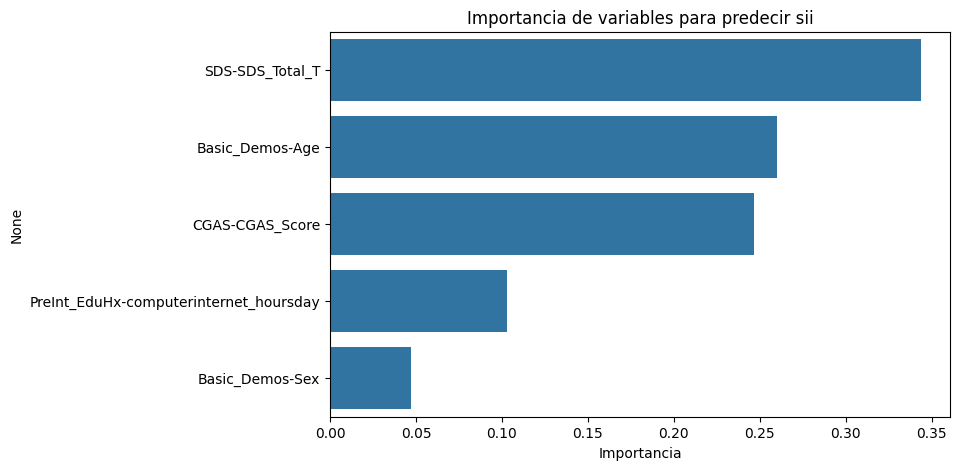

In [11]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title('Importancia de variables para predecir sii')
plt.xlabel('Importancia')
plt.show()

**Conclusiones:**

- Ranking de importancia de variables para predecir sii:
  1. **SDS_Total_T (sueño)**: ~0.34 — la variable MÁS importante
  2. **Edad**: ~0.26
  3. **CGAS_Score (funcionamiento general)**: ~0.25
  4. **Horas de pantalla**: ~0.10
  5. **Sexo**: ~0.05 — la menos importante, con diferencia

- Hallazgo destacado: el **sueño es el predictor más fuerte**, por delante 
  incluso de la edad y de las horas de pantalla. Esto es un resultado 
  relevante y algo inesperado para la narrativa del proyecto: 
  el factor que más "pesa" en el riesgo de uso problemático de internet 
  no son las horas de pantalla en sí, sino la calidad del sueño

- Las horas de pantalla (la variable "estrella" del proyecto) tienen 
  una importancia moderada (~0.10), considerablemente menor que sueño, 
  edad o funcionamiento general

- El sexo apenas influye en las predicciones del modelo (~0.05), 
  pese a que en el EDA (pasos 27-28) se observaron diferencias 
  proporcionales entre hombres y mujeres — el modelo no las considera 
  muy determinantes comparadas con el resto de variables

- **Para Tableau/memoria**: este gráfico es un resultado muy potente. 
  Sugiere que, aunque el proyecto se centra en "pantallas", el sueño 
  y la edad son factores igual o más relevantes para identificar 
  el riesgo — un matiz importante para el mensaje "positivo y negativo" 
  del proyecto (no todo es culpa de las pantallas)

## 📌 Conclusiones generales del Modelo ML — Dashboard 2

### Objetivo
Predecir el nivel de severidad de uso problemático de internet (sii, 
0=Ninguno a 3=Severo) a partir de variables demográficas y de salud 
(edad, sexo, horas de pantalla, funcionamiento general, sueño), 
excluyendo PCIAT_Total para evitar que el modelo "memorice" la fórmula 
de la variable objetivo.

### Modelo elegido
Random Forest Classifier (100 árboles, class_weight='balanced' para 
compensar el fuerte desbalance de clases: 71% sii=0, solo 0.8% sii=3).

### Resultados
- Accuracy general: 64.39% (por debajo del 71% que daría un modelo 
  "tonto" que siempre prediga sii=0, pero ese modelo tonto tendría 
  0% de detección en el resto de clases)
- El modelo distingue bien la clase 0 (precision 0.89, recall 0.73)
- Detecta una parte real de los casos leves y moderados (recall 0.47 
  y 0.39 respectivamente)
- No logra identificar ningún caso severo (sii=3), debido a la extrema 
  escasez de ejemplos (32 de 3.872, un 0.8%)
- Los errores del modelo son mayoritariamente entre clases adyacentes 
  (0↔1, 1↔2, 2↔3), no saltos extremos

### Hallazgo principal: importancia de variables
1. Sueño (SDS_Total_T) — el predictor MÁS importante (~34%)
2. Edad (~26%)
3. Funcionamiento general / CGAS (~25%)
4. Horas de pantalla (~10%)
5. Sexo (~5%)

### Implicación para el proyecto
El resultado matiza la narrativa "pantallas → problema": el sueño y la 
edad pesan más que las horas de pantalla en sí a la hora de predecir 
el riesgo. Esto refuerza el enfoque equilibrado (positivo y negativo) 
del proyecto, mostrando que el panorama es más complejo que una relación 
directa pantalla-problema.

### Limitaciones
- Clase severa (sii=3) sin representación suficiente para ser predicha
- Modelo entrenado sobre datos parcialmente imputados (ver limitación 
  documentada en el EDA, paso 24)
- Accuracy global no es la métrica más informativa dado el desbalance; 
  el classification_report (por clase) es más representativo del 
  rendimiento real

### Producto final
Modelo entrenado, evaluado y con interpretación de variables clave, 
listo para incluir en la memoria y como apoyo narrativo del Dashboard 2 
en Tableau.